## Benzene GNN Training

In [85]:
import numpy as np

import torch
import torch.nn.functional as F
import glob
from torch.nn import Linear, ModuleList
from torch_geometric.nn import GCNConv, GATConv, GINConv, global_add_pool
from torch_geometric.nn.models import MLP
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from tqdm import tqdm
from scipy.optimize import curve_fit


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


### 1. Load the Dataset


In [2]:
def load_graphs(datapath: str):
    data = np.load(datapath, allow_pickle = True)
    att, X, y = data['attr'], data['X'], data['y']
    ylist = [y[i][0] for i in range(y.shape[0])]

    X = X[0]

    all_graphs = []

    for i in range(len(X)):
        x = torch.from_numpy(X[i]['nodes'])
        edge_attr = torch.from_numpy(X[i]['edges'])
        y = torch.tensor([int(ylist[i])], dtype = torch.long)

        e1 = torch.from_numpy(X[i]['receivers']).long()
        e2 = torch.from_numpy(X[i]['senders']).long()

        edge_index = torch.stack([e1, e2])

        data_i = Data(
            x = x,
            y = y,
            edge_attr = edge_attr,
            edge_index = edge_index
        )

        all_graphs.append(data_i) # Add to larger list
        node_imp = torch.from_numpy(att[i][0]['nodes']).float()

        # Error-check:
        assert att[i][0]['n_edge'] == X[i]['n_edge'], 'Num: {}, Edges different sizes'.format(i)
        assert node_imp.shape[0] == x.shape[0], 'Num: {}, Shapes: {} vs. {}'.format(i, node_imp.shape[0], x.shape[0]) \
            + '\nExp: {} \nReal:{}'.format(att[i][0], X[i])

    return all_graphs

In [153]:
def get_loaders(path):
    data_list = load_graphs(path)
    test_size = int(0.10 * len(data_list))
    val_size = int(0.10 * len(data_list))
    train_size = len(data_list)-test_size-val_size

    train_dataset, test_dataset, val_dataset = torch.utils.data.random_split(data_list, [train_size, test_size, val_size])

    batch_size = 64
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    in_channels = data_list[0].num_node_features
    num_classes = 2

    print(f"Total graphs: {len(data_list)}")
    print(f"Training graphs: {len(train_dataset)}")
    print(f"Testing graphs: {len(test_dataset)}")
    print(f"Validation graphs: {len(val_dataset)}")
    print(f"Node Features Dimension (in_channels): {in_channels}")
    print(f"Classes: {num_classes}")


    return train_loader, test_loader, val_loader, in_channels, num_classes


### 2. Define the Networks (GCN, GAT, GIN)

In [4]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, dropout=0.5):
        super(GCN, self).__init__()
        
        self.in_channels = in_channels
        self.hidden_channels = hidden_channels
        self.out_channels = out_channels
        self.dropout = dropout
        self.num_layers = num_layers

        self.convs = ModuleList()
        self.convs.append(GCNConv(in_channels, hidden_channels))
        for _ in range(num_layers - 1):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
            
        self.lin = Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            x = F.relu(x)
            if i < self.num_layers - 1:
                x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = global_add_pool(x, batch)

        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin(x)
        
        return x


class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, dropout=0.5):
        super(GAT, self).__init__()
        
        self.in_channels = in_channels
        self.hidden_channels = hidden_channels
        self.out_channels = out_channels
        self.dropout = dropout
        self.num_layers = num_layers
        
        self.convs = torch.nn.ModuleList()
        self.convs.append(GATConv(in_channels, hidden_channels))
        for _ in range(num_layers - 1):
            self.convs.append(GATConv(hidden_channels, hidden_channels))
            
        self.lin = Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        for i in range(self.num_layers):
            x = self.convs[i](x, edge_index)
            x = F.elu(x)
            if i < self.num_layers - 1:
                x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = global_add_pool(x, batch)

        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin(x)
        
        return x


class GIN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, dropout=0.5):
        super(GIN, self).__init__()
        
        self.in_channels = in_channels
        self.hidden_channels = hidden_channels
        self.out_channels = out_channels
        self.dropout = dropout
        self.num_layers = num_layers

        self.convs = torch.nn.ModuleList()
        for i in range(num_layers):
            input_dim = in_channels if i == 0 else hidden_channels
            self.convs.append(
                GINConv(MLP([input_dim, 32, hidden_channels], dropout=self.dropout))
            )
            
        self.lin = Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        for i in range(self.num_layers):
            x = self.convs[i](x, edge_index)
            x = F.relu(x)
            if i < self.num_layers - 1:
                x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = global_add_pool(x, batch)

        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin(x)
        
        return x


### 3. Training Loop

In [5]:
def train(loader, graph_model, optimizer, criterion):
    graph_model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()

        out = graph_model(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * data.num_graphs
        
    return total_loss / len(loader.dataset)

@torch.no_grad()
def test(loader, graph_model, criterion):
    graph_model.eval()
    correct = 0
    total_loss = 0
    for data in loader:
        data = data.to(device)
    
        out = graph_model(data.x, data.edge_index, data.batch)    
        batch_loss = criterion(out, data.y).item()
        total_loss += batch_loss * data.num_graphs 
        
        pred = out.argmax(dim=1)
        correct += int((pred == data.y).sum())
        
    return (
        correct / len(loader.dataset),
        total_loss / len(loader.dataset)
    )

In [6]:
class EarlyStopper:
    def __init__(self, patience=1, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float("inf")

    def early_stop(self, validation_loss):
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
        elif validation_loss >= (self.min_validation_loss * (1 + self.min_delta)):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

## Full Training Function

In [7]:
def full_training(model, model_name, train_loader, val_loader, test_loader):
    epochs = 500
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    criterion = (
        torch.nn.CrossEntropyLoss() if model.out_channels > 1 else torch.nn.BCELoss()
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=50, min_lr=1e-5, threshold=1e-3
    )
    early_stopper = EarlyStopper(patience=100)
    torch.manual_seed(1234)
    best_val_acc = 0

    history = {'train_loss':[], 'test_acc':[], 'best_val_acc':0}

    for epoch in range(epochs):
        train_loss = train(train_loader, model, optimizer, criterion)
        model.eval()
        val_acc, val_loss = test(loader=val_loader, graph_model=model, criterion=criterion)
        test_acc, test_loss = test(loader=test_loader, graph_model=model, criterion=criterion)
        scheduler.step(val_loss)
        print(
            f"\nEpoch: {epoch}"
            f"\nTrain Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Test Loss: {test_loss:.4f}"
            f"\nVal Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}"
        )
        history["train_loss"].append(train_loss)
        history["test_acc"].append(test_acc)

        if epoch == 1 or val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f"./models/best_{model_name}.pth")
            print(
                f"Best model saved at epoch {epoch}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}"
            )


        if early_stopper.early_stop(val_loss):
            print(f"Early stopping at epoch {epoch}")
            break
    
    history['best_val_acc'] = best_val_acc
    print("Training Complete!")
    return history

## GCN Training

In [8]:
gcn_history = {}

train_loader, test_loader, val_loader, in_channels, num_classes = get_loaders('benzene_data/benzene.npz')

hidden_channels = [64, 64, 128, 32]
for i in range(4):
    print(f"\nStarting GCN Training for {i+1} Layer Model...")
    gcn_model = GCN(
        in_channels=in_channels, 
        hidden_channels=hidden_channels[i], 
        out_channels=num_classes,
        num_layers=i+1,
        dropout=0.5
    ).to(device)
    history = full_training(gcn_model, f'gcn_{i+1}_layered_benzene', train_loader, val_loader, test_loader)
    gcn_history[str(i)] = history

Total graphs: 12000
Training graphs: 9600
Testing graphs: 1200
Validation graphs: 1200
Node Features Dimension (in_channels): 14
Classes: 2

Starting GCN Training for 1 Layer Model...

Epoch: 0
Train Loss: 0.6175, Val Loss: 0.5119, Test Loss: 0.5301
Val Acc: 0.7825, Test Acc: 0.7733
Best model saved at epoch 0, Val Acc: 0.7825, Test Acc: 0.7733

Epoch: 1
Train Loss: 0.5433, Val Loss: 0.5205, Test Loss: 0.5442
Val Acc: 0.7400, Test Acc: 0.7433
Best model saved at epoch 1, Val Acc: 0.7400, Test Acc: 0.7433

Epoch: 2
Train Loss: 0.5342, Val Loss: 0.4823, Test Loss: 0.4996
Val Acc: 0.7925, Test Acc: 0.7867
Best model saved at epoch 2, Val Acc: 0.7925, Test Acc: 0.7867

Epoch: 3
Train Loss: 0.5264, Val Loss: 0.4816, Test Loss: 0.5040
Val Acc: 0.7850, Test Acc: 0.7875

Epoch: 4
Train Loss: 0.5225, Val Loss: 0.4620, Test Loss: 0.4859
Val Acc: 0.8083, Test Acc: 0.7942
Best model saved at epoch 4, Val Acc: 0.8083, Test Acc: 0.7942

Epoch: 5
Train Loss: 0.5199, Val Loss: 0.4609, Test Loss: 0.482

## GAT Training

In [20]:
gat_history = {}

train_loader, test_loader, val_loader, in_channels, num_classes = get_loaders('benzene_data/benzene.npz')

hidden_channels = [128, 128, 64, 128]
for i in range(4):
    print(f"\nStarting GAT Training for {i+1} Layer Model...")
    gat_model = GAT(
        in_channels=in_channels, 
        hidden_channels=hidden_channels[i], 
        out_channels=num_classes,
        num_layers=i+1,
        dropout=0.5
    ).to(device)
    history = full_training(gat_model, f'gat_{i+1}_layered_benzene', train_loader, val_loader, test_loader)
    gat_history[str(i)] = history

Total graphs: 12000
Training graphs: 9600
Testing graphs: 1200
Validation graphs: 1200
Node Features Dimension (in_channels): 14
Classes: 2

Starting GAT Training for 1 Layer Model...

Epoch: 0
Train Loss: 0.5955, Val Loss: 0.5209, Test Loss: 0.5409
Val Acc: 0.7700, Test Acc: 0.7517
Best model saved at epoch 0, Val Acc: 0.7700, Test Acc: 0.7517

Epoch: 1
Train Loss: 0.5455, Val Loss: 0.5381, Test Loss: 0.5555
Val Acc: 0.7208, Test Acc: 0.7367
Best model saved at epoch 1, Val Acc: 0.7208, Test Acc: 0.7367

Epoch: 2
Train Loss: 0.5434, Val Loss: 0.5097, Test Loss: 0.5306
Val Acc: 0.7675, Test Acc: 0.7625
Best model saved at epoch 2, Val Acc: 0.7675, Test Acc: 0.7625

Epoch: 3
Train Loss: 0.5393, Val Loss: 0.4993, Test Loss: 0.5249
Val Acc: 0.7750, Test Acc: 0.7717
Best model saved at epoch 3, Val Acc: 0.7750, Test Acc: 0.7717

Epoch: 4
Train Loss: 0.5329, Val Loss: 0.6073, Test Loss: 0.6339
Val Acc: 0.6942, Test Acc: 0.7017

Epoch: 5
Train Loss: 0.5384, Val Loss: 0.5022, Test Loss: 0.533

## GIN Training

In [10]:
gin_history = {}

train_loader, test_loader, val_loader, in_channels, num_classes = get_loaders('benzene_data/benzene.npz')

hidden_channels = [16, 128, 128, 64]
for i in range(4):
    print(f"\nStarting GIN Training for {i+1} Layer Model...")
    gin_model = GIN(
        in_channels=in_channels, 
        hidden_channels=hidden_channels[i], 
        out_channels=num_classes,
        num_layers=i+1,
        dropout=0.5
    ).to(device)
    history = full_training(gin_model, f'gin_{i+1}_layered_benzene', train_loader, val_loader, test_loader)
    gin_history[str(i)] = history

Total graphs: 12000
Training graphs: 9600
Testing graphs: 1200
Validation graphs: 1200
Node Features Dimension (in_channels): 14
Classes: 2

Starting GIN Training for 1 Layer Model...

Epoch: 0
Train Loss: 0.6323, Val Loss: 0.5012, Test Loss: 0.5253
Val Acc: 0.7817, Test Acc: 0.7633
Best model saved at epoch 0, Val Acc: 0.7817, Test Acc: 0.7633

Epoch: 1
Train Loss: 0.5419, Val Loss: 0.4827, Test Loss: 0.5061
Val Acc: 0.7725, Test Acc: 0.7692
Best model saved at epoch 1, Val Acc: 0.7725, Test Acc: 0.7692

Epoch: 2
Train Loss: 0.5166, Val Loss: 0.4661, Test Loss: 0.4801
Val Acc: 0.7967, Test Acc: 0.7808
Best model saved at epoch 2, Val Acc: 0.7967, Test Acc: 0.7808

Epoch: 3
Train Loss: 0.5122, Val Loss: 0.4148, Test Loss: 0.4327
Val Acc: 0.8275, Test Acc: 0.8217
Best model saved at epoch 3, Val Acc: 0.8275, Test Acc: 0.8217

Epoch: 4
Train Loss: 0.5132, Val Loss: 0.4460, Test Loss: 0.4616
Val Acc: 0.8075, Test Acc: 0.8058

Epoch: 5
Train Loss: 0.5023, Val Loss: 0.4317, Test Loss: 0.453

## Plotting Training Loss and Accuracy

The plots are smoothed to enhance readability. For Training, a 5 epoch sliding window is used, for Accuracy a 15 epoch window.

In [ ]:
import matplotlib.pyplot as plt


def smoothing(data, window_size):
    weights = np.ones(window_size) / window_size
    return np.convolve(data, weights, mode='valid')


def plot_history(history, model_name):
    colors = ['orange', 'red', 'purple', 'blue']

    plt.figure(figsize=(8,4))
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'Training Loss {model_name}')
    for i in range(len(history.keys())):
        smoothed_train = smoothing(history[str(i)]['train_loss'], 20)
        plt.plot(smoothed_train, color=colors[i], label=f'{i+1}-layered')
    plt.grid()
    plt.legend(loc='best')
    plt.tight_layout()
    plt.savefig(f"training_plots/losses_{model_name}_benzene.png", dpi=300, bbox_inches="tight")

    plt.figure(figsize=(10,5))
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'Test Accuracy {model_name}')
    for i in range(len(history.keys())):
        smoothed_test = smoothing(history[str(i)]['test_acc'], 20)
        plt.plot(smoothed_test, color=colors[i], label=f'{i+1}-layered')
        plt.axhline(y=history[str(i)]['best_val_acc'], color=colors[i], linestyle='--', linewidth=0.5, label=f'Best saved {i+1}-layered model: acc={history[str(i)]['best_val_acc']:.3f}')
    plt.grid()
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
    plt.savefig(f"training_plots/accuracies_{model_name}_benzene.png", dpi=300, bbox_inches="tight")

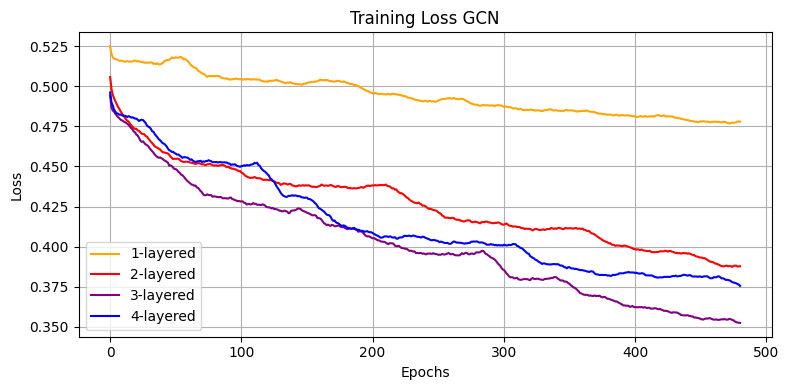

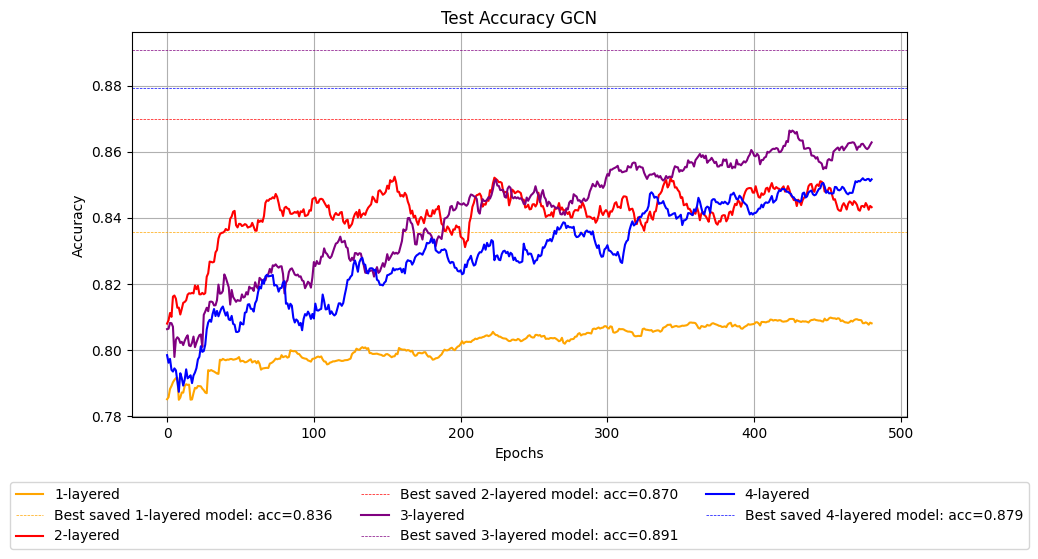

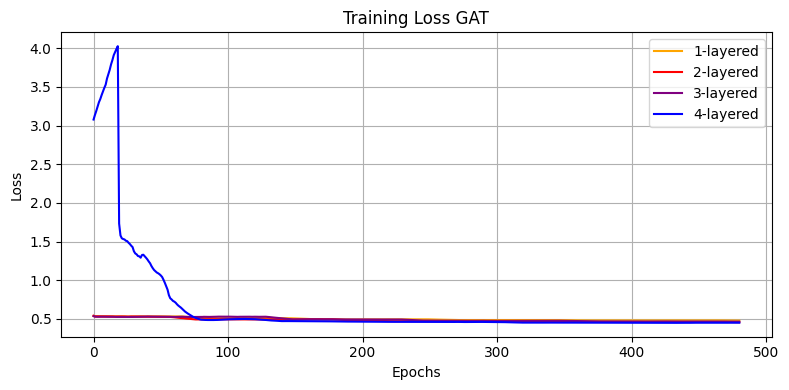

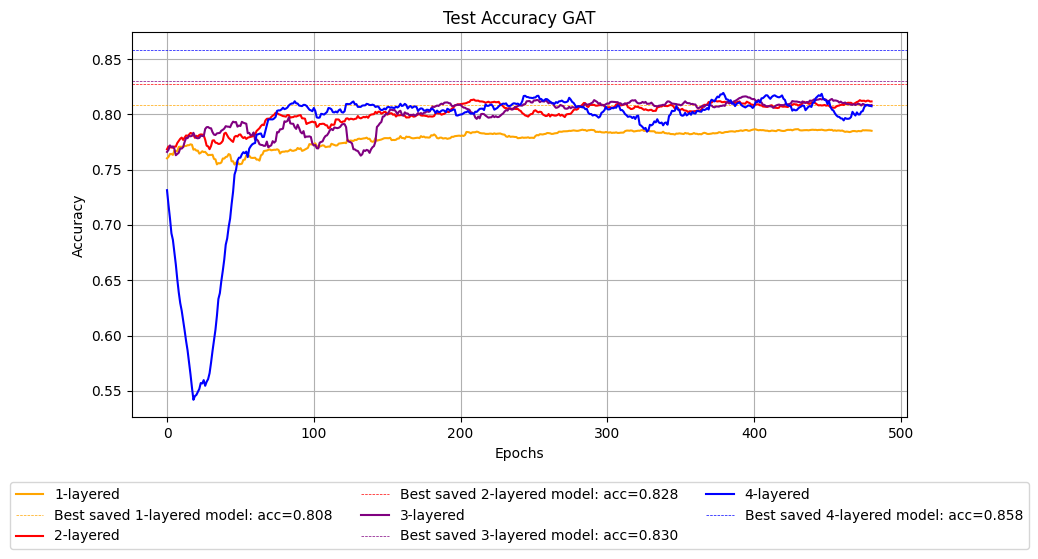

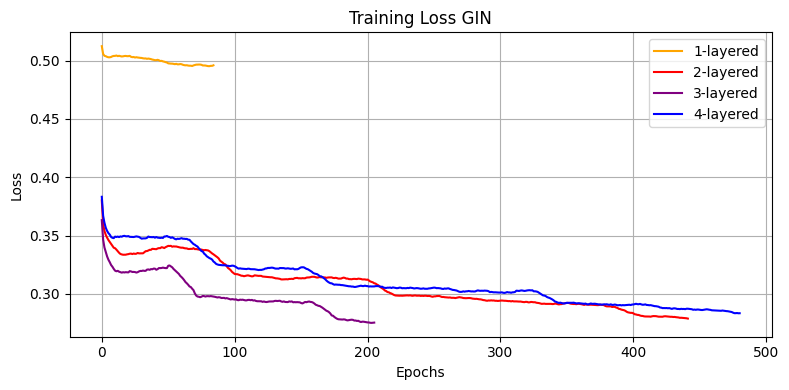

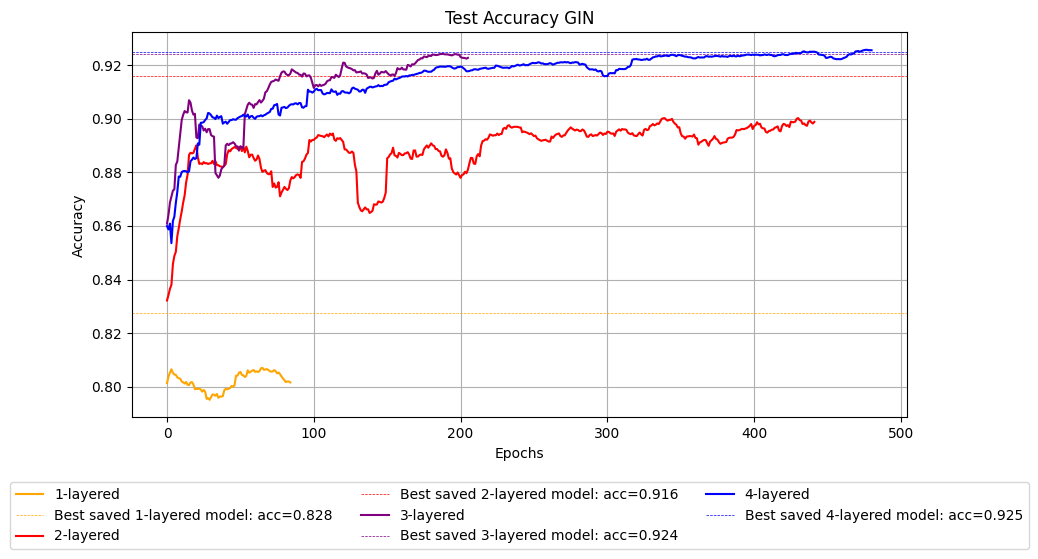

In [58]:
plot_history(gcn_history, 'GCN')
plot_history(gat_history, 'GAT')
plot_history(gin_history, 'GIN')

## Ablation

This is where we compare GraphSHAPIQ to the ExactComputer on a real dataset, to assess how accurate our estimations are.

In [43]:
from shapiq import ExactComputer

from shapiq.graph import GraphGame, GraphSHAPIQ

def run_ablation(deep_model, data_point) -> float:
    # make it a game
    # output = deep_model(data_point.x, data_point.edge_index, data_point.batch).squeeze(dim=0).detach().numpy()
    # predicted_class = int(np.argmax(output, axis=0))
    game = GraphGame(
        model=deep_model,
        x_graph=data_point,
        # class_index=predicted_class,
        baseline_strategy='min',
        output_dim=2
    )

    # compute values with GraphSHAPIQ
    # print("Computing GraphSHAPIQ values...")
    explainer = GraphSHAPIQ(game)
    if explainer.total_budget > 20_000:
        # skip
        print(f"Skipping due to high budget {explainer.total_budget}")
        return 0.0
    explainer_values, _ = explainer.explain(order=game.n_players)

    # compute the exact game
    # print("Computing exact values...")
    computer = ExactComputer(game=game, n_players=game.n_players)
    exact_values = computer(index="Moebius", order=game.n_players)

    # compare the results
    differences = exact_values - explainer_values
    differences_sum = sum(np.abs(differences.values))
    # print("Exact values:", exact_values)
    # print("GraphSHAPIQ values:", explainer_values)
    # print("Difference:", differences)
    # print("Sum of diff:", differences_sum)

    return differences_sum

Ablation for Graphs with less than 12 Nodes 

In [ ]:
def run_ablation_experiment(N_RUNS, MAX_NODES):
    # get the explanation instances
    all_graphs = load_graphs("benzene_data/benzene.npz")
    loader = DataLoader(all_graphs, batch_size=64, shuffle=False)
    explanation_instances = []
    for data in loader:
        for i in range(data.num_graphs):
            explanation_instances.append(data[i])

    # select only instances with less than MAX_NODES nodes
    small_nodes = []
    for graph in explanation_instances:
        if graph.num_nodes <= MAX_NODES:
            small_nodes.append(graph)
    print(f"Number of instances with less than {MAX_NODES} nodes:", len(small_nodes))

    diffs = {
        'gcn' : {'1':0.0,'2':0.0,'3':0.0,'4':0.0},
        'gat' : {'1':0.0,'2':0.0,'3':0.0,'4':0.0},
        'gin' : {'1':0.0,'2':0.0,'3':0.0,'4':0.0}
    }
    models_config = {
        'gcn' : {'1':64,'2':64,'3':128,'4':32},
        'gat' : {'1':128,'2':128,'3':64,'4':128},
        'gin' : {'1':16,'2':128,'3':128,'4':64}
    }
    for model_name in ['gcn', 'gat', 'gin']:
        for layer in range(1,5):
            print(f"\nStarting Ablation for {model_name} Model with {layer} Layers...")
            print("Loading Model...")
            hidden = int(models_config[str(model_name)][str(layer)])
            if model_name=='gcn':
                model = GCN(in_channels=14, hidden_channels=hidden, out_channels=2, num_layers=layer).to(device)
                model.load_state_dict(torch.load(f"models/best_{model_name}_{layer}_layered_benzene.pth"), strict=False)
            elif model_name=='gat':
                model = GAT(in_channels=14, hidden_channels=hidden, out_channels=2, num_layers=layer).to(device)
                model.load_state_dict(torch.load(f"models/best_{model_name}_{layer}_layered_benzene.pth"), strict=False)
            else:
                model = GIN(in_channels=14, hidden_channels=hidden, out_channels=2, num_layers=layer).to(device)
                model.load_state_dict(torch.load(f"models/best_{model_name}_{layer}_layered_benzene.pth"), strict=False)
            print("Loading Successful!")
            for i in tqdm(range(N_RUNS)):
                diff = run_ablation(model, small_nodes[i])
                diffs[str(model_name)][str(layer)] += diff
            print(f"Average difference {layer} layered {model_name}: {(diffs[str(model_name)][str(layer)]/N_RUNS):.7f}")


In [59]:
run_ablation_experiment(N_RUNS = 15, MAX_NODES = 12)

Number of instances with less than 12 nodes: 653

Starting Ablation for gcn Model with 1 Layers...
Loading Model...
Loading Successful!


100%|██████████| 15/15 [00:04<00:00,  3.69it/s]


Average difference 1 layered gcn: 0.0003070

Starting Ablation for gcn Model with 2 Layers...
Loading Model...
Loading Successful!


100%|██████████| 15/15 [00:07<00:00,  1.92it/s]


Average difference 2 layered gcn: 0.0000506

Starting Ablation for gcn Model with 3 Layers...
Loading Model...
Loading Successful!


...

Average difference 2 layered gin: 0.0006645

Starting Ablation for gin Model with 3 Layers...
Loading Model...
Loading Successful!


100%|██████████| 15/15 [00:20<00:00,  1.39s/it]


Average difference 3 layered gin: 0.0000000

Starting Ablation for gin Model with 4 Layers...
Loading Model...
Loading Successful!


100%|██████████| 15/15 [00:27<00:00,  1.85s/it]


Average difference 4 layered gin: 0.0000000


In [52]:
run_ablation_experiment(N_RUNS = 10, MAX_NODES = 6)

Number of instances with less than 6 nodes: 10

Starting Ablation for gcn Model with 1 Layers...
Loading Model...
Loading Successful!


100%|██████████| 10/10 [00:00<00:00, 74.81it/s]


Average difference 1 layered gcn: 0.0000016

Starting Ablation for gcn Model with 2 Layers...
Loading Model...
Loading Successful!


100%|██████████| 10/10 [00:00<00:00, 33.76it/s]


Average difference 2 layered gcn: 0.0000000

Starting Ablation for gcn Model with 3 Layers...
Loading Model...
Loading Successful!


...

Average difference 2 layered gin: 0.0000000

Starting Ablation for gin Model with 3 Layers...
Loading Model...
Loading Successful!


100%|██████████| 10/10 [00:00<00:00, 20.78it/s]


Average difference 3 layered gin: 0.0000000

Starting Ablation for gin Model with 4 Layers...
Loading Model...
Loading Successful!


100%|██████████| 10/10 [00:01<00:00,  9.08it/s]


Average difference 4 layered gin: 0.0000000


## Complexity Analysis

In [83]:
import os

from tqdm import tqdm

import pandas as pd
from shapiq.graph import GraphGame, GraphSHAPIQ


models_config = {
    'gcn' : {'1':64,'2':64,'3':128,'4':32},
    'gat' : {'1':128,'2':128,'3':64,'4':128},
    'gin' : {'1':16,'2':128,'3':128,'4':64}
}

def evaluate_complexity(n_layers, model_name, all_samples_to_explain):
    gshap_budget = {}
    gshap_budget_est = {}
    players = {}
    max_neighborhood_size = {}
    print(f"\nStarting Complexity Evalutation for {model_name} Model with {n_layers} Layers...")
    print("Loading Model...")
    hidden = int(models_config[str(model_name)][str(n_layers)])
    if model_name=='gcn':
        model = GCN(in_channels=14, hidden_channels=hidden, out_channels=2, num_layers=n_layers).to(device)
        model.load_state_dict(torch.load(f"models/best_{model_name}_{n_layers}_layered_benzene.pth"), strict=False)
    elif model_name=='gat':
        model = GAT(in_channels=14, hidden_channels=hidden, out_channels=2, num_layers=n_layers).to(device)
        model.load_state_dict(torch.load(f"models/best_{model_name}_{n_layers}_layered_benzene.pth"), strict=False)
    else:
        model = GIN(in_channels=14, hidden_channels=hidden, out_channels=2, num_layers=n_layers).to(device)
        model.load_state_dict(torch.load(f"models/best_{model_name}_{n_layers}_layered_benzene.pth"), strict=False)

    for data_id, x_graph in enumerate(tqdm(all_samples_to_explain, desc='Evaluating Samples')):
        game = GraphGame(
            model=model,
            x_graph=x_graph,
            baseline_strategy='min',
            output_dim=2
        )
        gSHAP = GraphSHAPIQ(game)

        gshap_budget[data_id] = gSHAP.total_budget
        players[data_id] = gSHAP.n_players
        max_neighborhood_size[data_id] = gSHAP.l_hop_distance
        gshap_budget_est[data_id] = gSHAP.budget_estimated

    results = pd.DataFrame(
        index=gshap_budget.keys(), data=gshap_budget.values(), columns=["budget"]
    )
    results["budget_upper_bound"] = gshap_budget_est
    results["max_neighborhood_size"] = max_neighborhood_size
    results["n_players"] = players

    save_name = "_".join(["complexity_benzene_" + str(model_name) + "_" + str(n_layers)])
    save_path = os.path.join("results", save_name + ".csv")
    results.to_csv(save_path)
    print("Results saved to: " + save_path)


all_graphs = load_graphs("benzene_data/benzene.npz")
loader = DataLoader(all_graphs, batch_size=64, shuffle=False)
all_samples_to_explain = []
for data in loader:
    for i in range(data.num_graphs):
        all_samples_to_explain.append(data[i])

for model_name in ['gcn', 'gat', 'gin']:
    for layer in range(1,5):
        evaluate_complexity(n_layers=int(layer), model_name=model_name, all_samples_to_explain=all_samples_to_explain)


Starting Complexity Evalutation for gcn Model with 1 Layers...
Loading Model...


Evaluating Samples...: 100%|██████████| 12000/12000 [00:08<00:00, 1499.90it/s]


Results saved to: results/complexity_benzene_gcn_1.csv


Starting Complexity Evalutation for gcn Model with 2 Layers...
Loading Model...


Evaluating Samples...: 100%|██████████| 12000/12000 [00:17<00:00, 667.34it/s]


Results saved to: results/complexity_benzene_gcn_2.csv


Starting Complexity Evalutation for gcn Model with 3 Layers...
Loading Model...


...

Results saved to: results/complexity_benzene_gin_2.csv


Starting Complexity Evalutation for gin Model with 3 Layers...
Loading Model...


Evaluating Samples...: 100%|██████████| 12000/12000 [01:53<00:00, 105.40it/s]


Results saved to: results/complexity_benzene_gin_3.csv


Starting Complexity Evalutation for gin Model with 4 Layers...
Loading Model...


Evaluating Samples...: 100%|██████████| 12000/12000 [24:12<00:00,  8.26it/s] 


Results saved to: results/complexity_benzene_gin_4.csv



## Plot Complexity Results

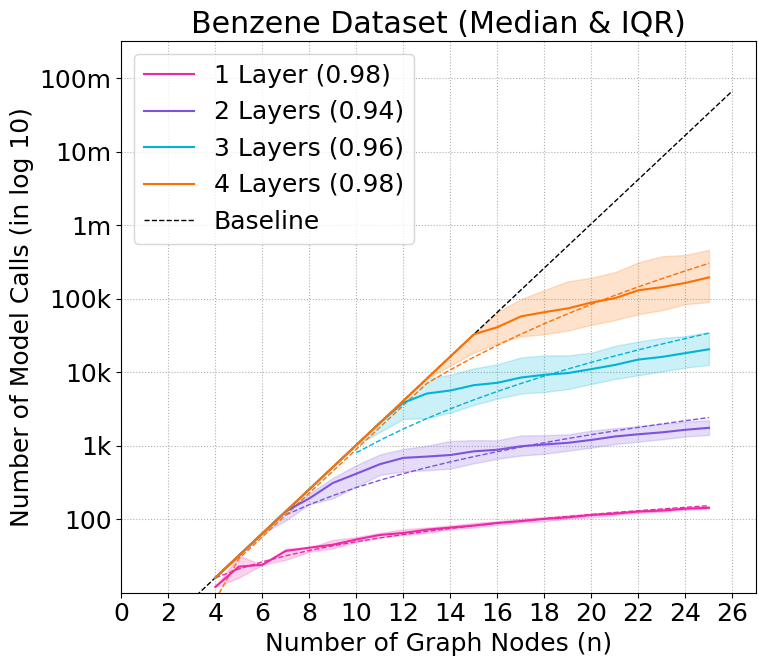

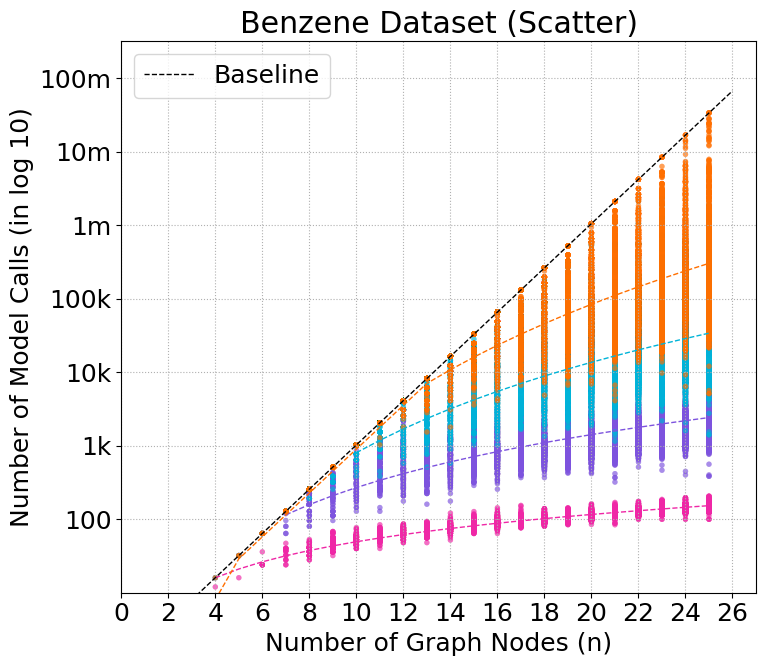


--- Median Speed-Up Multiplier vs Baseline by Layer ---
Layer 1: ~10^4x
Layer 2: ~10^3x
Layer 3: ~10^2x
Layer 4: ~10^1x


In [ ]:
import os
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def logarithmic_function(x, a, b):
    # Used to fit the trend curve
    return a * np.log(x) + b


def plot_trend_curve(x_val, y_val, color):
    # Fit and plot logarithmic trend
    popt, _ = curve_fit(logarithmic_function, x_val, y_val)
    y_fit = logarithmic_function(x_val, *popt)

    # Only plot points under the baseline threshold
    idx_to_plot = y_fit < x_val * np.log10(2)
    plt.plot(x_val[idx_to_plot], y_fit[idx_to_plot], color=color, linestyle="--", linewidth=1)

    # Calculate R-squared
    ss_res = np.sum((y_val - y_fit)**2)
    ss_tot = np.sum((y_val - np.mean(y_val)) ** 2)
    return 1 - (ss_res / ss_tot)


def plot_naive_budget(node_range):
    plt.plot(
        node_range,
        node_range * np.log10(2),
        linestyle="--",
        linewidth=1,
        color="black",
        label="Baseline",
    )


def plot_complexity_by_layers(plot_dataset, model_name, save_dir, scatter=False):
    COLORS = {"1": "#ef27a6", "2": "#7d53de", "3": "#00b4d8", "4": "#ff6f00"}
    plt.rcParams.update({"font.size": 18, "figure.figsize": (8, 7)})

    fig, ax = plt.subplots()

    # Pre-compute statistics grouping strictly by layers and players
    medians = plot_dataset.groupby(["n_layers", "n_players"])["log10_budget"].median()
    q1 = plot_dataset.groupby(["n_layers", "n_players"])["log10_budget"].quantile(0.25)
    q3 = plot_dataset.groupby(["n_layers", "n_players"])["log10_budget"].quantile(0.75)

    for n_layers in sorted(plot_dataset["n_layers"].unique()):
        plot_color = COLORS.get(str(n_layers), "black")
        plot_label = f"{n_layers} Layer{'s' if str(n_layers) != '1' else ''}"

        # Ensure data exists for this layer
        if str(n_layers) not in medians.index.get_level_values(0):
            continue

        plot_medians = medians.loc[n_layers]
        plot_q1_layer = q1.loc[n_layers]
        plot_q3_layer = q3.loc[n_layers]

        # Isolate the raw data for this specific layer
        layer_raw_data = plot_dataset[plot_dataset["n_layers"] == str(n_layers)]

        # Fit and plot the trend curve if possible
        try:
            r_squared = plot_trend_curve(plot_medians.index, plot_medians.values, plot_color)
            plot_label += f" ({np.round(r_squared, 2)})"
        except Exception:
            pass

        # Either Scatter or band plot
        if scatter:
            ax.scatter(
                layer_raw_data["n_players"],
                layer_raw_data["log10_budget"],
                color=plot_color,
                s=15,
                alpha=0.3,
                edgecolors='none', 
                zorder=1
            )
        else:
            ax.fill_between(plot_medians.index, plot_q1_layer, plot_q3_layer, alpha=0.2, color=plot_color, zorder=2)
            ax.plot(plot_medians.index, plot_medians.values, color=plot_color, linestyle="-", label=plot_label, zorder=3)
        

    # Axis customization
    min_x = max(0, plot_dataset["n_players"].min() - 2)
    max_x = min(plot_dataset["n_players"].max() + 2, 150)
    
    node_range = np.arange(min_x - min_x % 5, max_x, max(1, max_x // 10))
    plot_naive_budget(node_range)
    
    plt.xlim(min_x, max_x)
    plt.ylim(1, 8.5)
    plt.xticks(node_range)
    plt.yticks([2, 3, 4, 5, 6, 7, 8], ["100", "1k", "10k", "100k", "1m", "10m", "100m"])
    
    plt.ylabel("Number of Model Calls (in log 10)")
    plt.xlabel("Number of Graph Nodes (n)")
    
    legend_loc = "lower right" if max_x > 40 else "upper left"
    ax.legend(loc=legend_loc)
    
    # Adjust title formatting
    title_suffix = "(Scatter)" if scatter else "(Median & IQR)"
    if model_name == "All_Architectures":
        plt.title(f"Benzene Dataset {title_suffix}")
    else:
        plt.title(f"Benzene Dataset ({model_name.upper()}) {title_suffix}")
        
    plt.grid(True, linestyle=":")
    plt.tight_layout()

    # Save out the plot with a dynamic name based on whether it has scatter points
    os.makedirs(save_dir, exist_ok=True)
    file_suffix = "scatter" if scatter else "lines"
    save_path = os.path.join(save_dir, f"complexity_benzene_{model_name.lower()}_{file_suffix}.png")
    plt.savefig(save_path)
    plt.show()


if __name__ == "__main__":
    save_directory = "results"
    save_path_plots = os.path.join(save_directory, "plots")
    
    results = []

    # Iterate strictly through the available benzene files
    for file_path in glob.glob(os.path.join(save_directory, "complexity_benzene_*.csv")):
        file_name = os.path.basename(file_path).replace(".csv", "")
        
        # Expected naming convention: complexity_benzene_{model}_{layer}
        parts = file_name.split("_")
        if len(parts) == 4:
            _, dataset_name, model_name, n_layers = parts
            
            df = pd.read_csv(file_path)
            df["dataset_name"] = dataset_name
            df["model"] = model_name
            df["n_layers"] = str(n_layers)  # Cast to string to ensure dict lookup safety later
            results.append(df)

    if not results:
        print("No 'complexity_benzene_*.csv' files found in the 'results' directory.")
    else:
        # Combine all files into a single DataFrame
        all_data = pd.concat(results, ignore_index=True)
        all_data["log10_budget"] = np.log10(all_data["budget"].astype(float))

        # --- 1. PLOTS: Generate one WITH scatter points and one WITHOUT ---
        plot_complexity_by_layers(all_data, "All_Architectures", save_path_plots, scatter=False)
        plot_complexity_by_layers(all_data, "All_Architectures", save_path_plots, scatter=True)

        # --- 2. SPEED-UP MULTIPLIER ---
        all_data["log10_speed_up"] = (all_data["n_players"] * np.log10(2)) - all_data["log10_budget"]
        
        median_log10_speedup = all_data.groupby("n_layers")["log10_speed_up"].median()
        
        print("\n--- Median Speed-Up Multiplier vs Baseline by Layer ---")
        for layer, log_val in median_log10_speedup.items():
            # Round the log value to get the power (e.g., 10^2, 10^4)
            power = int(np.round(log_val))
            if power == 0:
                print(f"Layer {layer}: 1x (No significant speed-up)")
            else:
                print(f"Layer {layer}: ~10^{power}x")

## Plot Example Molecule with SI Values

Model prediction: 1
Computing exact Shapley Interactions...


/var/folders/q2/jbq21gwx0lx_cndh6l_s1zjm0000gn/T/ipykernel_92920/1033979441.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')


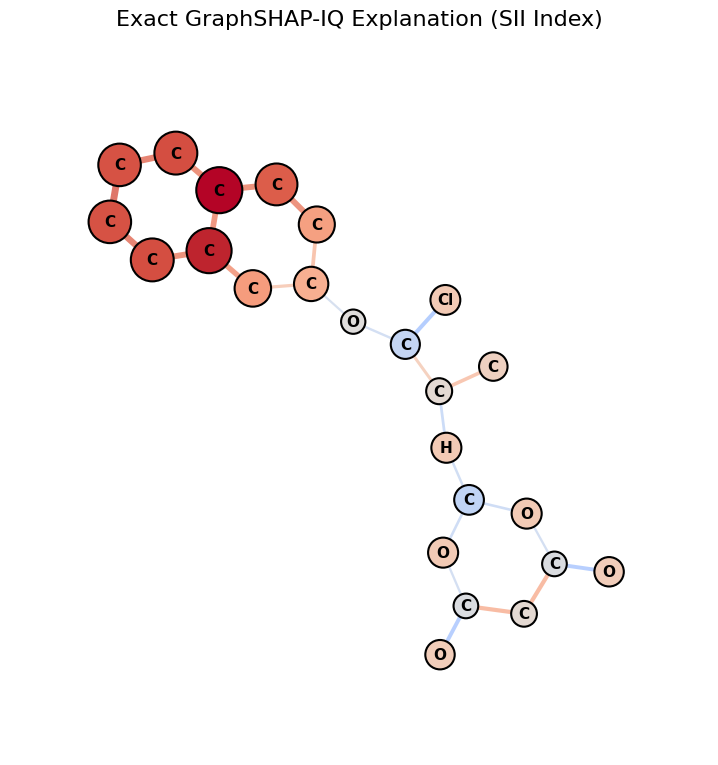

In [152]:
def explanation_graph_plot_native(
    interaction_values,
    edge_index: torch.Tensor,
    atom_labels: list,
    num_nodes: int,
    pos: dict,
    ax: plt.Axes = None,
):
    """Visualizes 1st and 2nd order interactions using pure Matplotlib."""
    if ax is None:
        ax = plt.gca()

    node_values = {}
    edge_values = {}
    max_val = 1e-9 

    # Extract 1st order (nodes) and 2nd order (edges) interaction values
    for subset, value in zip(interaction_values.interaction_lookup.keys(), interaction_values.values):
        val = float(value)
        max_val = max(max_val, abs(val))
        
        if len(subset) == 1:
            node_values[subset[0]] = val
        elif len(subset) == 2:
            u, v = subset
            edge_values[(u, v)] = val
            edge_values[(v, u)] = val

    cmap = cm.get_cmap('coolwarm')
    norm = mcolors.TwoSlopeNorm(vmin=-max_val, vcenter=0, vmax=max_val)

    # 1. Draw Edges (Lines)
    edge_index_np = edge_index.cpu().numpy()
    drawn_edges = set()
    
    for i in range(edge_index_np.shape[1]):
        u, v = int(edge_index_np[0, i]), int(edge_index_np[1, i])
        
        # Only draw undirected edges once
        edge_key = tuple(sorted([u, v]))
        if edge_key in drawn_edges:
            continue
        drawn_edges.add(edge_key)

        val = edge_values.get((u, v), edge_values.get((v, u), 0.0))
        color = cmap(norm(val))
        width = 1.0 + 5.0 * (abs(val) / max_val)
        
        x_coords = [pos[u][0], pos[v][0]]
        y_coords = [pos[u][1], pos[v][1]]
        
        ax.plot(x_coords, y_coords, color=color, linewidth=width, alpha=0.8, zorder=1)

    # 2. Draw Nodes (Scatter)
    node_x, node_y, node_colors, node_sizes = [], [], [], []
    
    for n in range(num_nodes):
        node_x.append(pos[n][0])
        node_y.append(pos[n][1])
        
        val = node_values.get(n, 0.0)
        node_colors.append(cmap(norm(val)))
        node_sizes.append(300 + 800 * (abs(val) / max_val))

    ax.scatter(
        node_x, node_y, 
        s=node_sizes, c=node_colors, 
        edgecolors='black', linewidths=1.5, zorder=2
    )
    
    # 3. Add Atomic Labels
    for n in range(num_nodes):
        ax.text(pos[n][0], pos[n][1], str(atom_labels[n]), 
                fontsize=11, fontweight='bold', color='black',
                ha='center', va='center', zorder=3)

    ax.axis('off')
    ax.margins(x=0.2, y=0.2)
    ax.set_aspect('equal')

def decode_atoms(feature_matrix: torch.Tensor):
    atom_mapping = {
        0: 'C',
        1: 'O',
        2: 'Cl',
        3: 'H',
        4: 'N',
        5: 'F',
        6: 'Br',
        7: 'S',
        8: 'P',
        9: 'I',
        10: 'Na',
        11: 'K',
        12: 'Li',
        13: 'Ca'
    }
    
    labels = []
    atom_indices = torch.argmax(feature_matrix, dim=1).cpu().numpy()
    for idx in atom_indices:
        labels.append(atom_mapping.get(int(idx), '?'))
    return labels

model = GCN(in_channels=14, hidden_channels=64, out_channels=2, num_layers=1)
model.load_state_dict(torch.load(f"models/best_gcn_1_layered_benzene.pth", map_location=device), strict=False)
model.eval()

all_graphs = load_graphs("benzene_data/benzene.npz")
loader = DataLoader(all_graphs, batch_size=1, shuffle=True)
x_graph = next(iter(loader)).to(device)
atom_labels = decode_atoms(x_graph.x)
out = model(x_graph.x, x_graph.edge_index, x_graph.batch)
pred = int(out.argmax(dim=1)[0].item())
print(f"Model prediction: {pred}")

game = GraphGame(
    model=model,
    x_graph=x_graph,
    baseline_strategy='min',
    output_dim=2
)
explainer = GraphSHAPIQ(game)
print("Computing exact Shapley Interactions...")
moebius, sii = explainer.explain(index='SII')
interaction_values = sii

fig, ax = plt.subplots(figsize=(8, 8))

# Dynamically generate the layout based on the loaded graph's size
import networkx as nx
num_nodes = x_graph.num_nodes if hasattr(x_graph, 'num_nodes') else x_graph.x.shape[0]
nx_graph = to_networkx(x_graph, to_undirected=True)
pos = nx.kamada_kawai_layout(nx_graph)

explanation_graph_plot_native(
    interaction_values=interaction_values, 
    edge_index=x_graph.edge_index, 
    atom_labels=atom_labels,
    num_nodes=num_nodes,
    pos=pos, 
    ax=ax
)

plt.title("Exact GraphSHAP-IQ Explanation (SII Index)", fontsize=16, pad=20)
plt.tight_layout()

output_file = "results/benzene_dynamic_native.png"
plt.savefig(output_file, format="pdf", bbox_inches="tight")